In [1]:
import os
os.getcwd()          # see where Python thinks it is
os.chdir(r'C:\Users\katha\OneDrive - Microsoft 365 der Universität Wien\Masterarbeit\Codes')

In [2]:
# ============================================================================
# SETUP: Load all model results and build df_long
# ============================================================================

import pickle
import numpy as np
import pandas as pd

MODEL_FILES = {
    "BiLSTM":           "results/bilstm_results.pkl",
    "CNN":              "results/cnn_improved_results.pkl",
    "TCN":              "results/tcn_dilated_results.pkl",
    "U-Net":            "results/unet_1d_results.pkl",
    "nn":               "results/nn_results.pkl",
    "XGBoost":          "results/xgboost_results.pkl",
    "BiLSTM (reduced)": "results/bilstm_reduced_results.pkl",
    "CNN (reduced)":    "results/cnn_improved_reduced_results.pkl",
    "TCN (reduced)":    "results/tcn_dilated_reduced_results.pkl",
    "U-Net (reduced)":  "results/unet_1d_reduced_results.pkl",
}

model_order = list(MODEL_FILES.keys())

def get_sport(athlete):
    if "Bike" in athlete:
        return "biking"
    if "Rowing" in athlete:
        return "rowing"
    return "rowing" if "Athlete12" in athlete else "biking"

def get_complexity(n_true):
    if n_true <= 10:
        return "Low (<=10)"
    if n_true <= 20:
        return "Medium (11-20)"
    return "High (>20)"

rows = []
for model_name, fpath in MODEL_FILES.items():
    with open(fpath, "rb") as f:
        pkg = pickle.load(f)
    results = pkg["results"] if isinstance(pkg, dict) else pkg
    for r in results:
        rows.append({
            "model":      model_name,
            "session":    r["session"],
            "athlete":    r["athlete"],
            "sport":      get_sport(r["athlete"]),
            "complexity": get_complexity(r["n_true"]),
            "f_beta":     r["f_beta"],
            "precision":  r["precision"],
            "recall":     r["recall"],
            "mae":        r["mean_error_sec"],
        })

df_long = pd.DataFrame(rows)
df_long["complexity"] = pd.Categorical(
    df_long["complexity"],
    categories=["Low (<=10)", "Medium (11-20)", "High (>20)"],
    ordered=True,
)
df_long["sport"] = pd.Categorical(df_long["sport"], categories=["biking", "rowing"])

print(f"Loaded {df_long['session'].nunique()} sessions, {df_long['model'].nunique()} models, {len(df_long)} rows total.")


Loaded 18 sessions, 10 models, 180 rows total.


In [3]:
# ============================================================================
# SUMMARY TABLES
# ============================================================================

# rename display label
df_long["model"] = df_long["model"].replace("nn", "FFNN")
model_order = ["FFNN" if m == "nn" else m for m in model_order]

# pre-compute session counts per category (used to label columns)
_n_total = df_long["session"].nunique()
_n_sport = df_long.drop_duplicates("session").groupby("sport", observed=False)["session"].count()
_n_comp  = df_long.drop_duplicates("session").groupby("complexity", observed=False)["session"].count()
_n_comp_sport = (
    df_long.drop_duplicates(subset=["session","sport","complexity"])
    .groupby(["complexity","sport"], observed=False)["session"].count()
)

# ── Table 1: All metrics for all models ──
print("=" * 60)
print(f"TABLE 1: Overall Metrics per Model  (n={_n_total} sessions)")
print("=" * 60)

table1_rows = []
for model in model_order:
    mdf = df_long[df_long['model'] == model]
    table1_rows.append({
        'Model': model,
        'F_beta': mdf['f_beta'].mean(),
        'Precision': mdf['precision'].mean(),
        'Recall': mdf['recall'].mean(),
        'MAE (sec)': mdf['mae'].mean(),
    })
table1 = pd.DataFrame(table1_rows).set_index('Model').round(2)
display(table1)

# ── Table 2: F_beta per model per sport ──
print()
print("=" * 60)
print("TABLE 2: F_beta per Model per Sport")
print("=" * 60)

pivot2 = df_long.pivot_table(
    values='f_beta', index='model', columns='sport', aggfunc='mean'
).round(2).loc[model_order]
pivot2.columns = [f"{c} (n={_n_sport[c]})" for c in pivot2.columns]
display(pivot2)

# ── Table 3: F_beta per model per complexity ──
print()
print("=" * 60)
print("TABLE 3: F_beta per Model per Complexity")
print("=" * 60)

pivot3 = df_long.pivot_table(
    values='f_beta', index='model', columns='complexity',
    aggfunc='mean', observed=False
).round(2).loc[model_order]
pivot3.columns = [f"{c} (n={_n_comp[c]})" for c in pivot3.columns]
display(pivot3)

# ── Table 4: F_beta per model per complexity x sport ──
print()
print("=" * 60)
print("TABLE 4: F_beta per Model per Complexity x Sport")
print("=" * 60)

pivot4 = df_long.pivot_table(
    values="f_beta",
    index="model",
    columns=["complexity", "sport"],
    aggfunc="mean",
    observed=False
).round(2).loc[model_order]
# rename leaf columns to include n
pivot4.columns = pd.MultiIndex.from_tuples(
    [(comp, f"{sport} (n={_n_comp_sport[(comp, sport)]})") for comp, sport in pivot4.columns],
    names=pivot4.columns.names
)
display(pivot4)

# ── Table 5: Best model per sport x complexity ──
print()
print("=" * 60)
print("TABLE 5: Session Count & Best Model per Sport x Complexity")
print("=" * 60)

session_info = df_long.drop_duplicates(subset=["session", "sport", "complexity"])
session_counts = session_info.groupby(["sport", "complexity"], observed=False)["session"].count().rename("n_sessions")
mean_fbeta = df_long.groupby(["sport", "complexity", "model"], observed=False)["f_beta"].mean()
best_model = mean_fbeta.groupby(level=["sport", "complexity"]).idxmax().map(lambda x: x[2]).rename("best_model")
best_fbeta = mean_fbeta.groupby(level=["sport", "complexity"]).max().round(2).rename("best_f_beta")
table5 = pd.concat([session_counts, best_model, best_fbeta], axis=1)
display(table5)


TABLE 1: Overall Metrics per Model  (n=18 sessions)


,F_beta,Precision,Recall,MAE (sec)
Model,,,,
BiLSTM,0.72,0.72,0.72,25.21
CNN,0.68,0.68,0.68,23.30
TCN,0.68,0.68,0.68,24.47
U-Net,0.67,0.67,0.67,32.56
FFNN,0.71,0.71,0.71,23.92
XGBoost,0.71,0.71,0.71,16.79
BiLSTM (reduced),0.53,0.53,0.53,42.16
CNN (reduced),0.63,0.63,0.63,44.87
TCN (reduced),0.58,0.58,0.58,55.84



TABLE 2: F_beta per Model per Sport


C:\Users\katha\AppData\Local\Temp\ipykernel_8412\3025188143.py:42: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = df_long.pivot_table(


,biking (n=6),rowing (n=12)
model,,
BiLSTM,0.69,0.74
CNN,0.56,0.74
TCN,0.60,0.72
U-Net,0.59,0.70
FFNN,0.69,0.72
XGBoost,0.58,0.77
BiLSTM (reduced),0.46,0.56
CNN (reduced),0.57,0.66
TCN (reduced),0.57,0.59


...


TABLE 4: F_beta per Model per Complexity x Sport


complexity         Low (<=10)              Medium (11-20)               \
sport            biking (n=1) rowing (n=7)   biking (n=2) rowing (n=4)   
model                                                                    
BiLSTM                   0.75         0.74           0.60         0.77   
CNN                      0.62         0.72           0.54         0.77   
TCN                      0.62         0.69           0.62         0.80   
U-Net                    0.75         0.70           0.70         0.75   
FFNN                     0.75         0.69           0.60         0.80   
XGBoost                  0.62         0.78           0.60         0.80   
BiLSTM (reduced)         0.50         0.55           0.46         0.60   
CNN (reduced)            0.50         0.64           0.49         0.69   
TCN (reduced)            0.62         0.57           0.60         0.64   
U-Net (reduced)          0.50         0.53           0.33         0.56   

complexity         High (>20)               
sport            biking (n=3) rowing (n=1)  
model                                       
BiLSTM                   0.72         0.62  
CNN                      0.55         0.73  
TCN                      0.57         0.56  
U-Net                    0.46         0.54  
FFNN                     0.74         0.65  
XGBoost                  0.56         0.58  
BiLSTM (reduced)         0.44         0.54  
CNN (reduced)            0.64         0.73  
TCN (reduced)            0.53         0.58  
U-Net (reduced)          0.57         0.56


TABLE 5: Session Count & Best Model per Sport x Complexity


C:\Users\katha\AppData\Local\Temp\ipykernel_8412\3025188143.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  best_model = mean_fbeta.groupby(level=["sport", "complexity"]).idxmax().map(lambda x: x[2]).rename("best_model")
C:\Users\katha\AppData\Local\Temp\ipykernel_8412\3025188143.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  best_fbeta = mean_fbeta.groupby(level=["sport", "complexity"]).max().round(2).rename("best_f_beta")


n_sessions best_model  best_f_beta
sport  complexity                                        
biking Low (<=10)               1     BiLSTM         0.75
       Medium (11-20)           2      U-Net         0.70
       High (>20)               3       FFNN         0.74
rowing Low (<=10)               7    XGBoost         0.78
       Medium (11-20)           4        TCN         0.80
       High (>20)               1        CNN         0.73

In [4]:
# ============================================================================
# TABLE 6: Feature Ablation — Full vs Reduced per Architecture
# ============================================================================

architectures = ["BiLSTM", "U-Net", "TCN", "CNN"]

ablation_rows = []
for arch in architectures:
    full_df    = df_long[df_long["model"] == arch]
    reduced_df = df_long[df_long["model"] == f"{arch} (reduced)"]

    full_mean    = full_df["f_beta"].mean()
    reduced_mean = reduced_df["f_beta"].mean()
    diff         = reduced_mean - full_mean

    # per-session win counts
    merged = full_df[["session", "f_beta"]].merge(
        reduced_df[["session", "f_beta"]],
        on="session", suffixes=("_full", "_reduced")
    )
    n_full    = (merged["f_beta_full"]    > merged["f_beta_reduced"]).sum()
    n_reduced = (merged["f_beta_reduced"] > merged["f_beta_full"]).sum()
    n_tie     = (merged["f_beta_full"]   == merged["f_beta_reduced"]).sum()

    ablation_rows.append({
        "Architecture":     arch,
        "Full F_beta":      round(full_mean, 3),
        "Reduced F_beta":   round(reduced_mean, 3),
        "Difference":       round(diff, 3),
        "Full/Reduced/Tie": f"{n_full} / {n_reduced} / {n_tie}",
    })

table6 = pd.DataFrame(ablation_rows).set_index("Architecture")

print("=" * 60)
print("TABLE 6: Feature Ablation — Full vs Reduced per Architecture")
print("=" * 60)
display(table6)


TABLE 6: Feature Ablation — Full vs Reduced per Architecture


,Full F_beta,Reduced F_beta,Difference,Full/Reduced/Tie
Architecture,,,,
BiLSTM,0.722,0.529,-0.193,13 / 0 / 5
U-Net,0.666,0.521,-0.145,11 / 4 / 3
TCN,0.678,0.584,-0.094,9 / 4 / 5
CNN,0.678,0.630,-0.048,10 / 4 / 4


In [5]:
# ============================================================================
# TABLE 7: Top-3 Models — Best per Sport x Complexity
# ============================================================================

# Identify top 3 models by overall mean F_beta (excluding reduced variants)
full_models = [m for m in model_order if "(reduced)" not in m]
overall_mean = (
    df_long[df_long["model"].isin(full_models)]
    .groupby("model")["f_beta"].mean()
    .sort_values(ascending=False)
)
top3 = list(overall_mean.index[:3])
print(f"Top-3 models overall: {top3}")
print()

top3_df = df_long[df_long["model"].isin(top3)]

# Mean F_beta per model per sport x complexity
pivot = top3_df.pivot_table(
    values="f_beta",
    index="model",
    columns=["complexity", "sport"],
    aggfunc="mean",
    observed=False,
).round(2).loc[top3]

# Best model per sport x complexity
best_model = pivot.idxmax(axis=0)

# Build readable table: rows = sport x complexity, cols = model scores + winner
combos = list(pivot.columns)
table7_rows = []
for (comp, sport) in combos:
    row = {"Sport": sport, "Complexity": comp}
    for m in top3:
        row[m] = round(pivot.loc[m, (comp, sport)], 2)
    row["Best model"] = best_model[(comp, sport)]
    table7_rows.append(row)

table7 = pd.DataFrame(table7_rows).set_index(["Sport", "Complexity"])

print("=" * 70)
print("TABLE 7: Top-3 Models — F_beta per Sport × Complexity")
print("=" * 70)
display(table7)


Top-3 models overall: ['BiLSTM', 'FFNN', 'XGBoost']

TABLE 7: Top-3 Models — F_beta per Sport × Complexity


,,BiLSTM,FFNN,XGBoost,Best model
Sport,Complexity,,,,
biking,Low (<=10),0.75,0.75,0.62,BiLSTM
rowing,Low (<=10),0.74,0.69,0.78,XGBoost
biking,Medium (11-20),0.60,0.60,0.60,BiLSTM
rowing,Medium (11-20),0.77,0.80,0.80,FFNN
biking,High (>20),0.72,0.74,0.56,FFNN
rowing,High (>20),0.62,0.65,0.58,FFNN


Loaded 18 sessions.


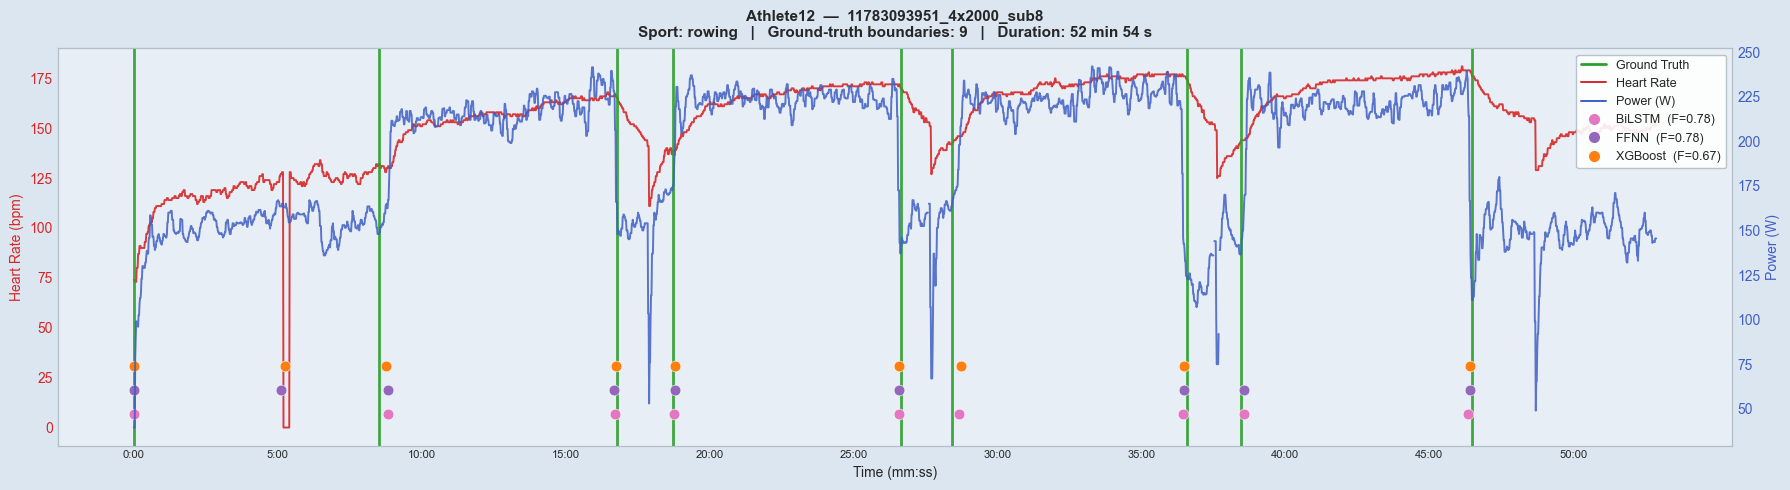

  Saved: plots/session_Athlete12_11783093951_4x2000_sub8.png


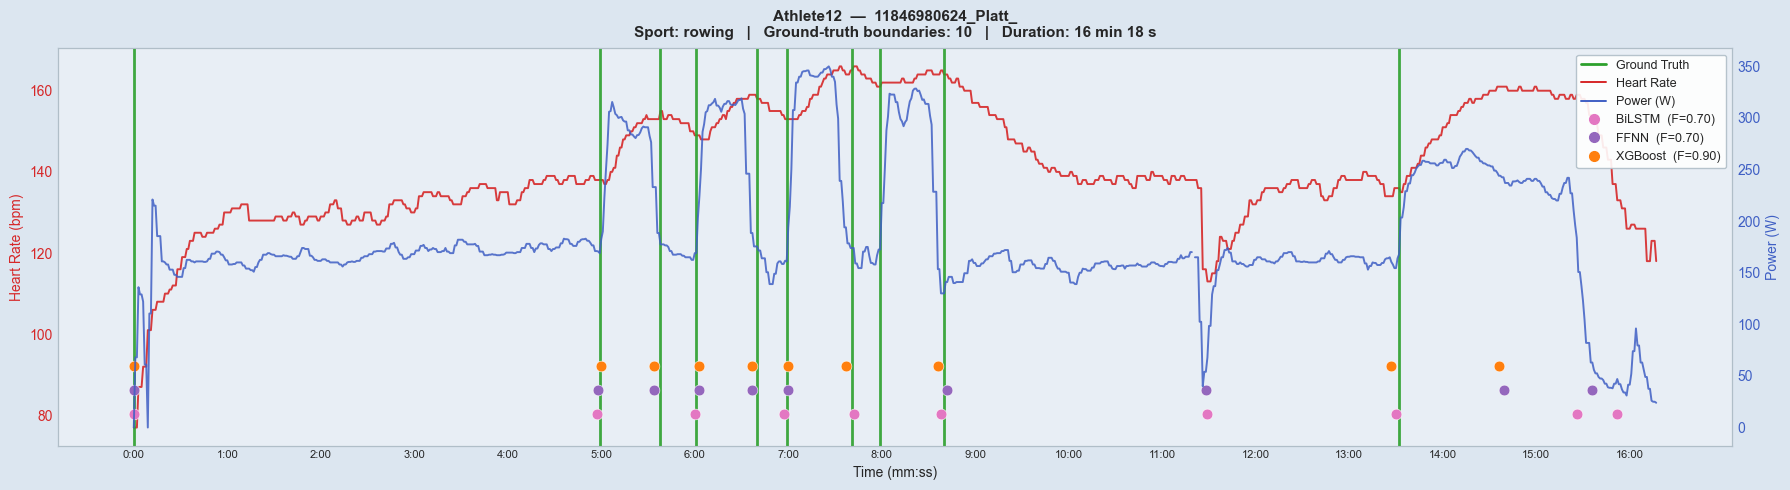

  Saved: plots/session_Athlete12_11846980624_Platt_.png


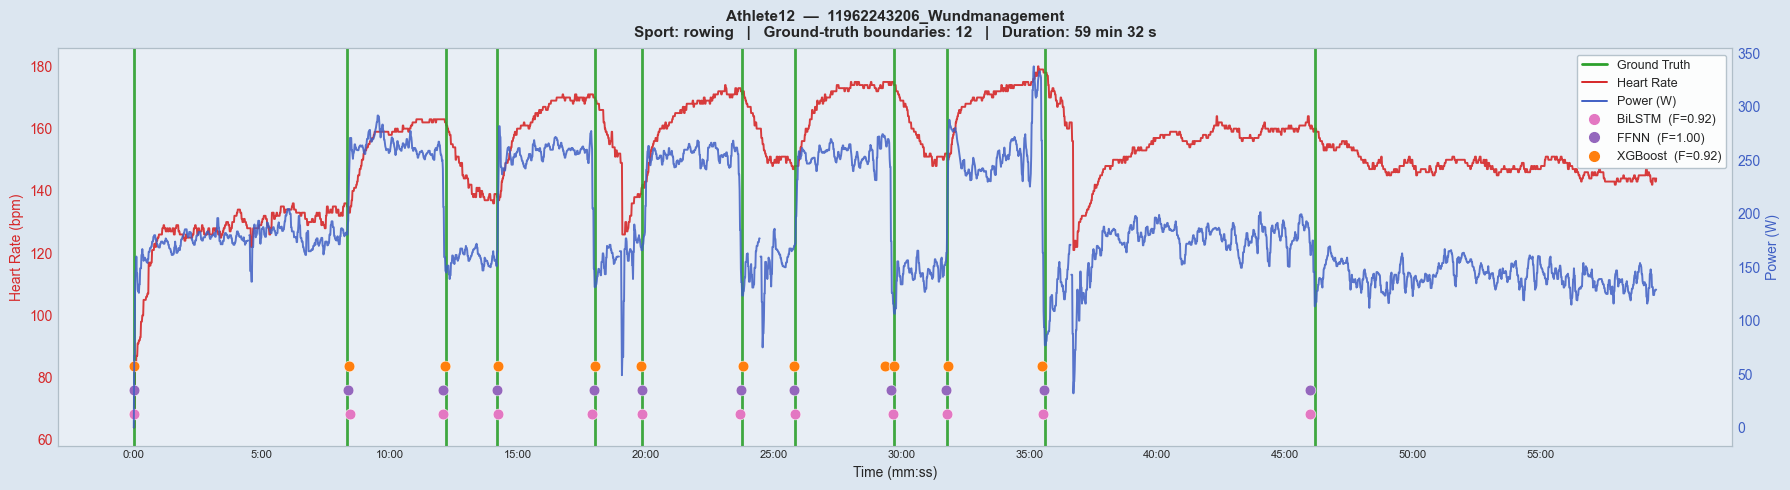

  Saved: plots/session_Athlete12_11962243206_Wundmanagement.png


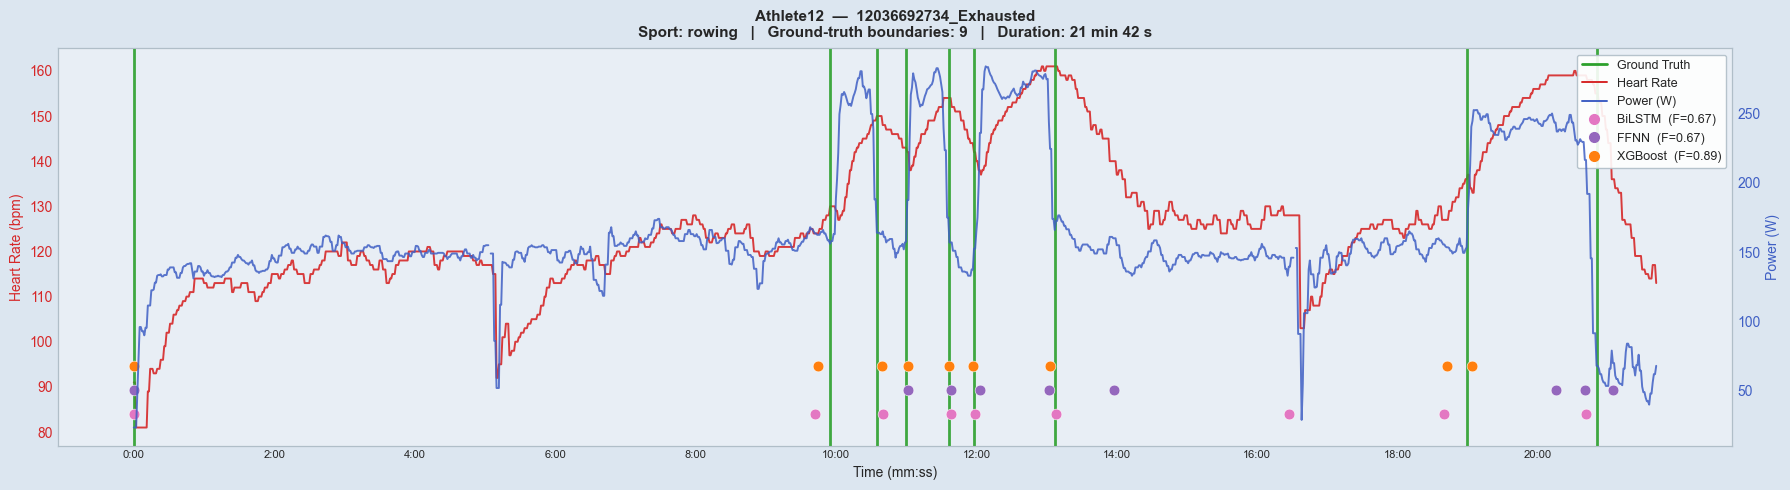

  Saved: plots/session_Athlete12_12036692734_Exhausted.png


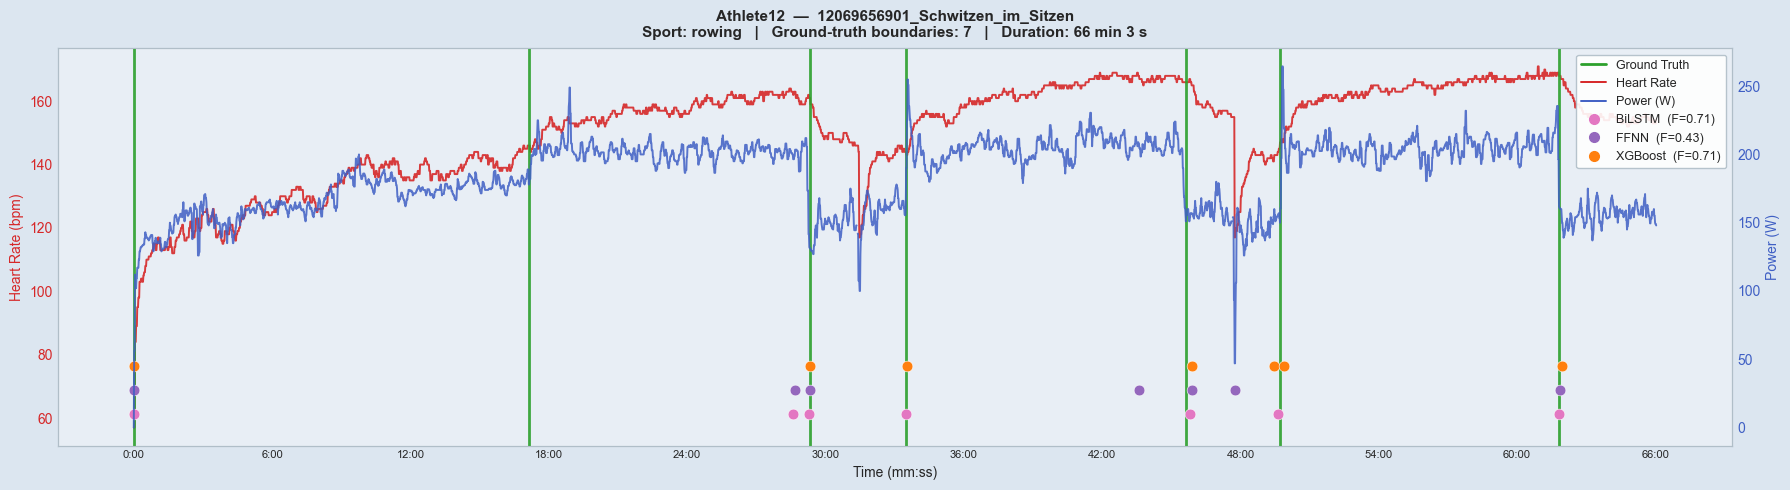

  Saved: plots/session_Athlete12_12069656901_Schwitzen_im_Sitzen.png


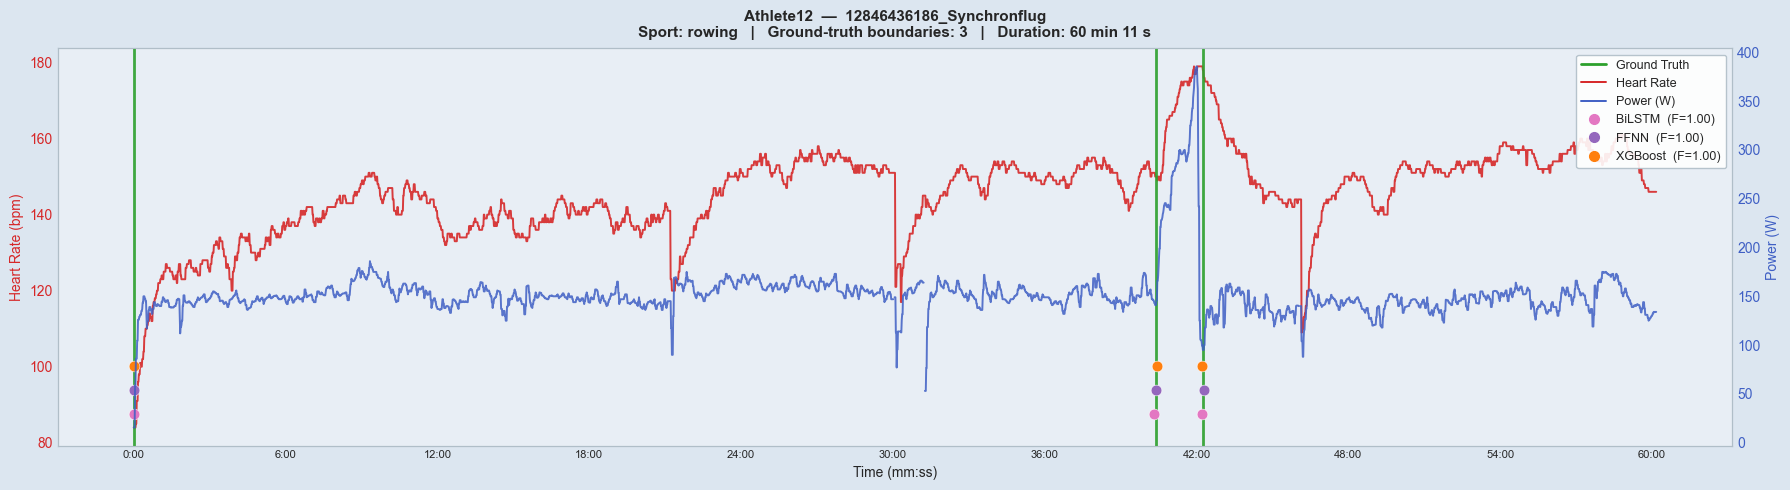

  Saved: plots/session_Athlete12_12846436186_Synchronflug.png


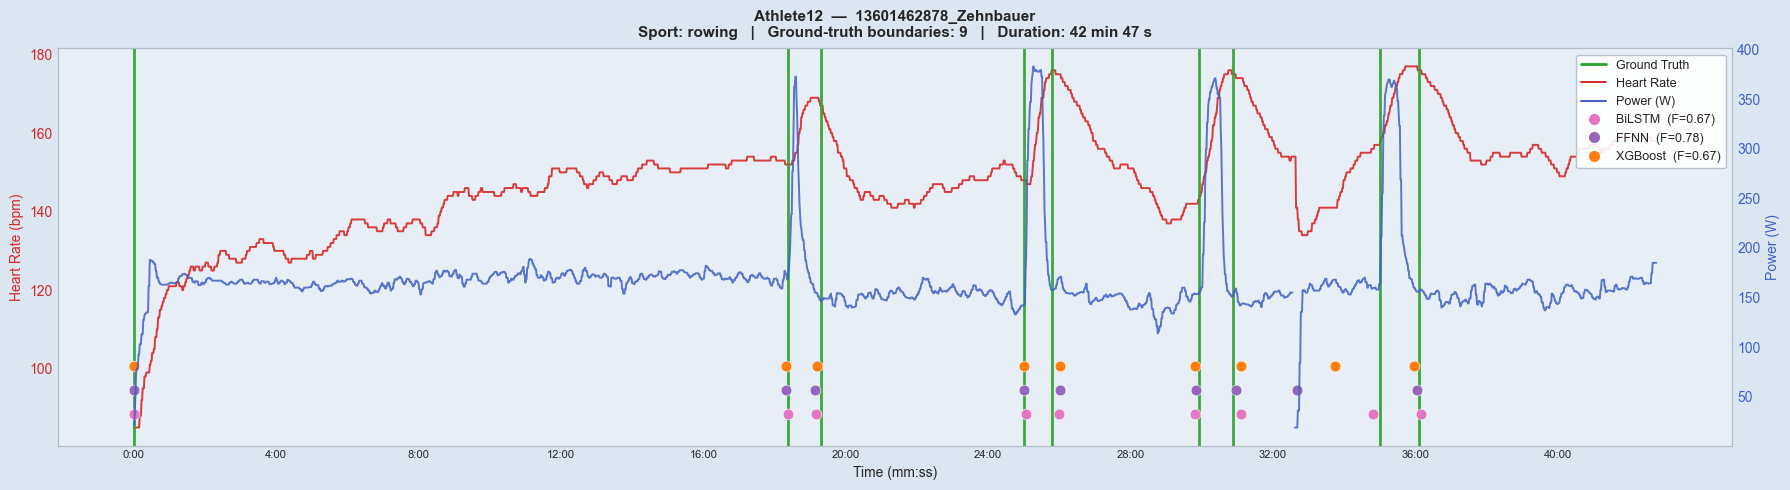

  Saved: plots/session_Athlete12_13601462878_Zehnbauer.png


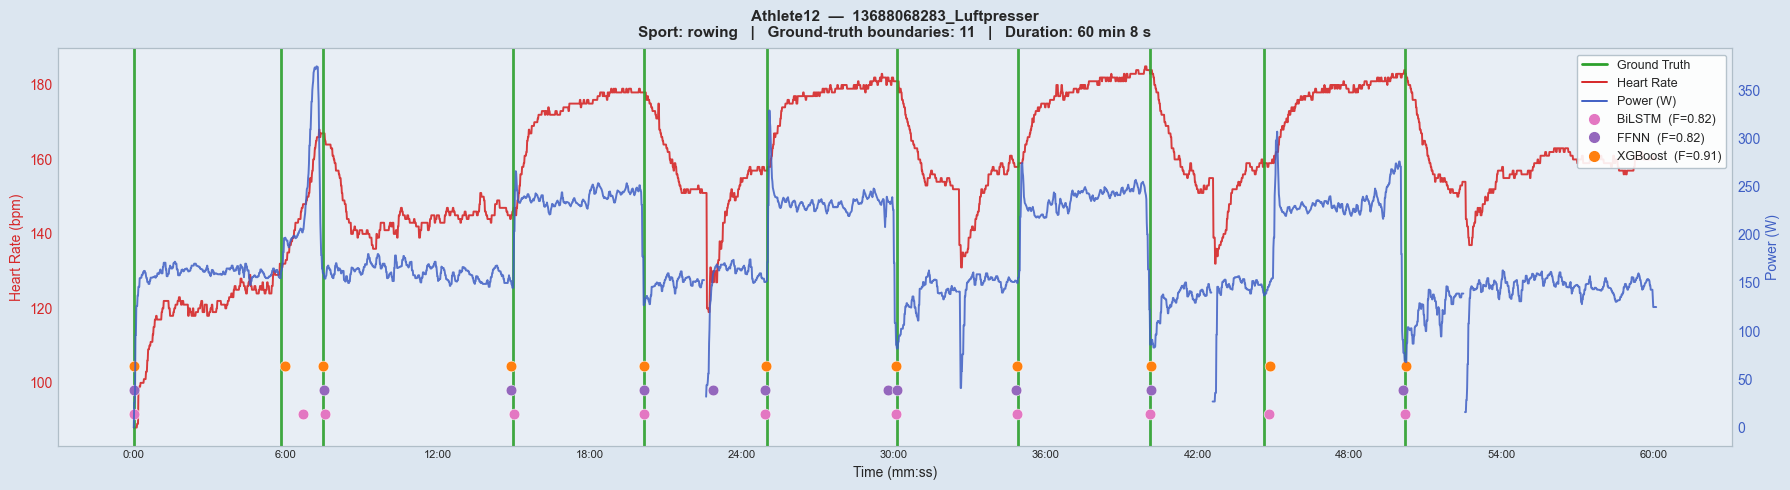

  Saved: plots/session_Athlete12_13688068283_Luftpresser.png


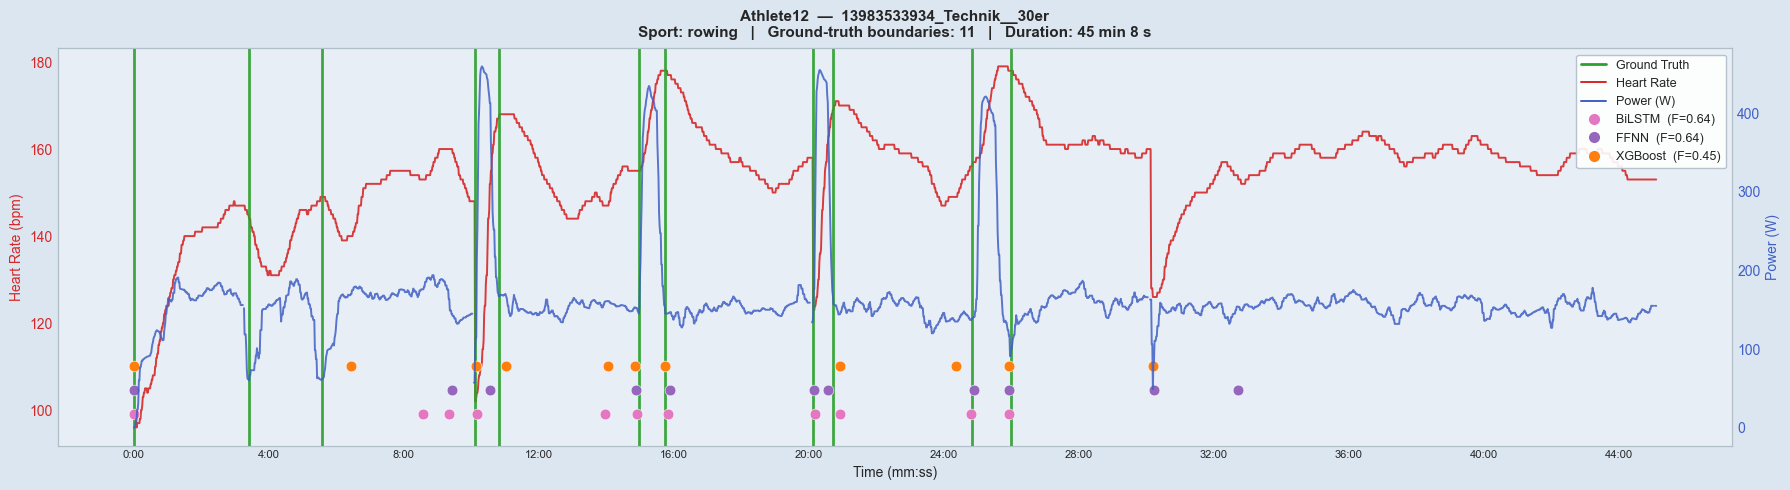

  Saved: plots/session_Athlete12_13983533934_Technik__30er.png


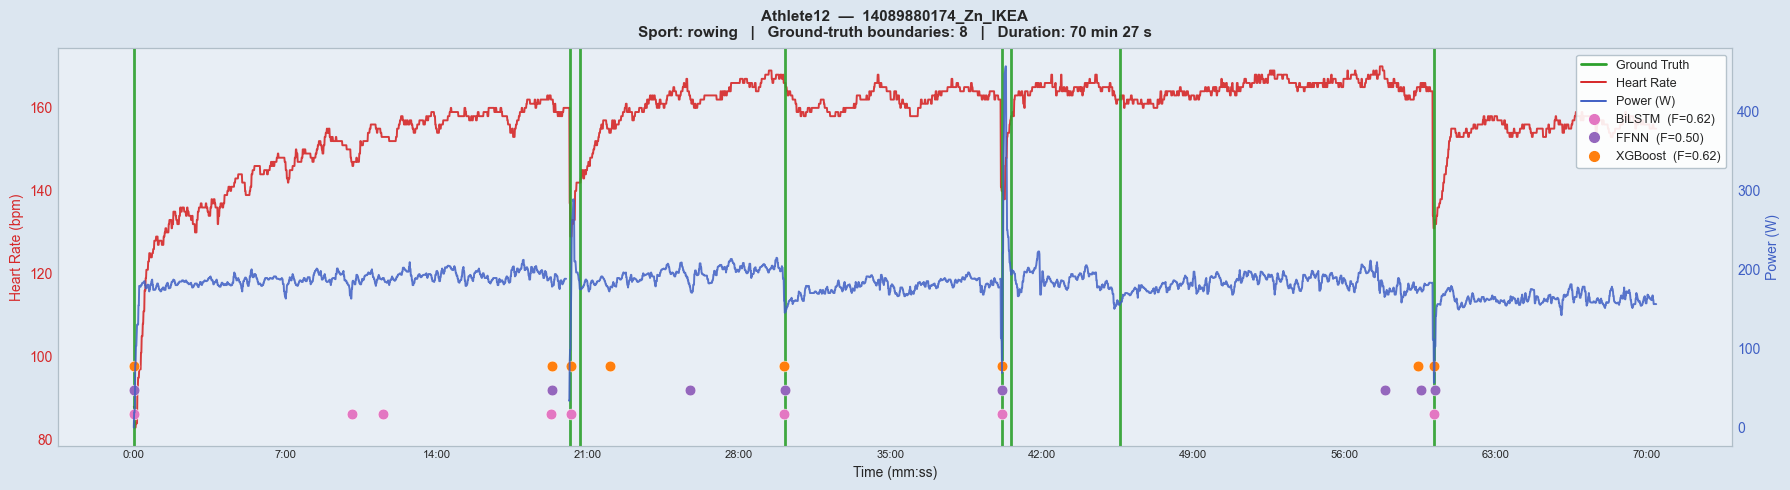

  Saved: plots/session_Athlete12_14089880174_Zn_IKEA.png


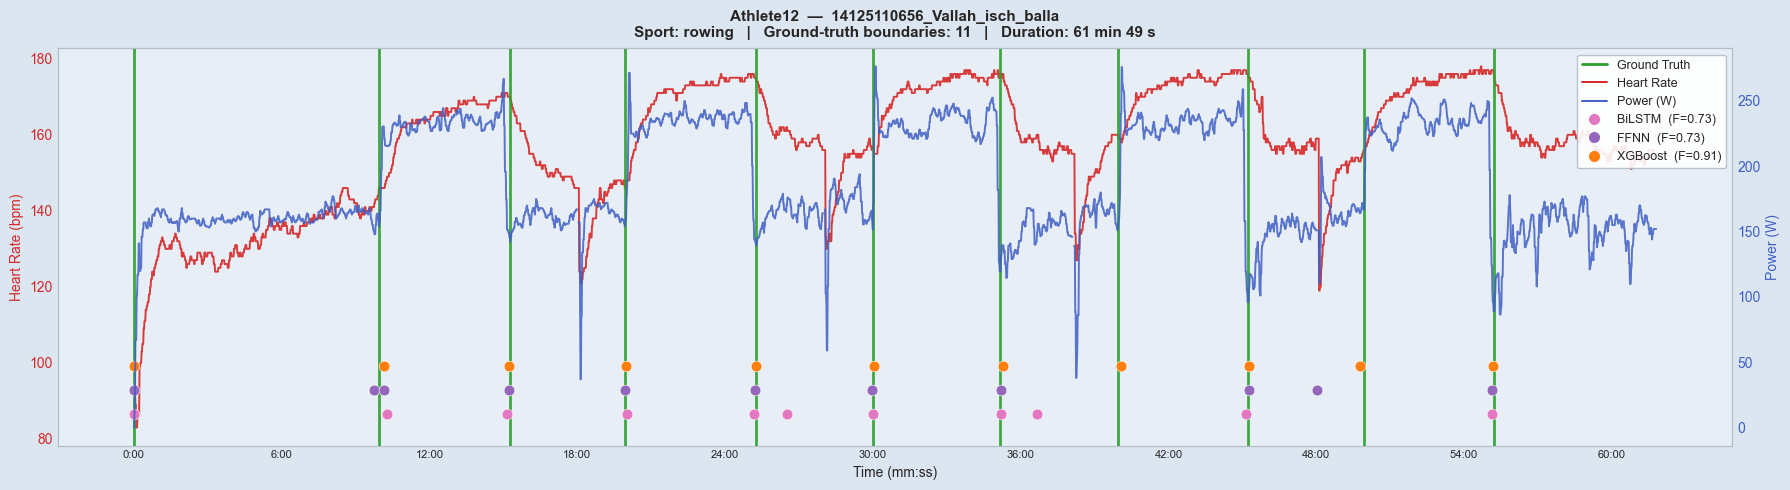

  Saved: plots/session_Athlete12_14125110656_Vallah_isch_balla.png


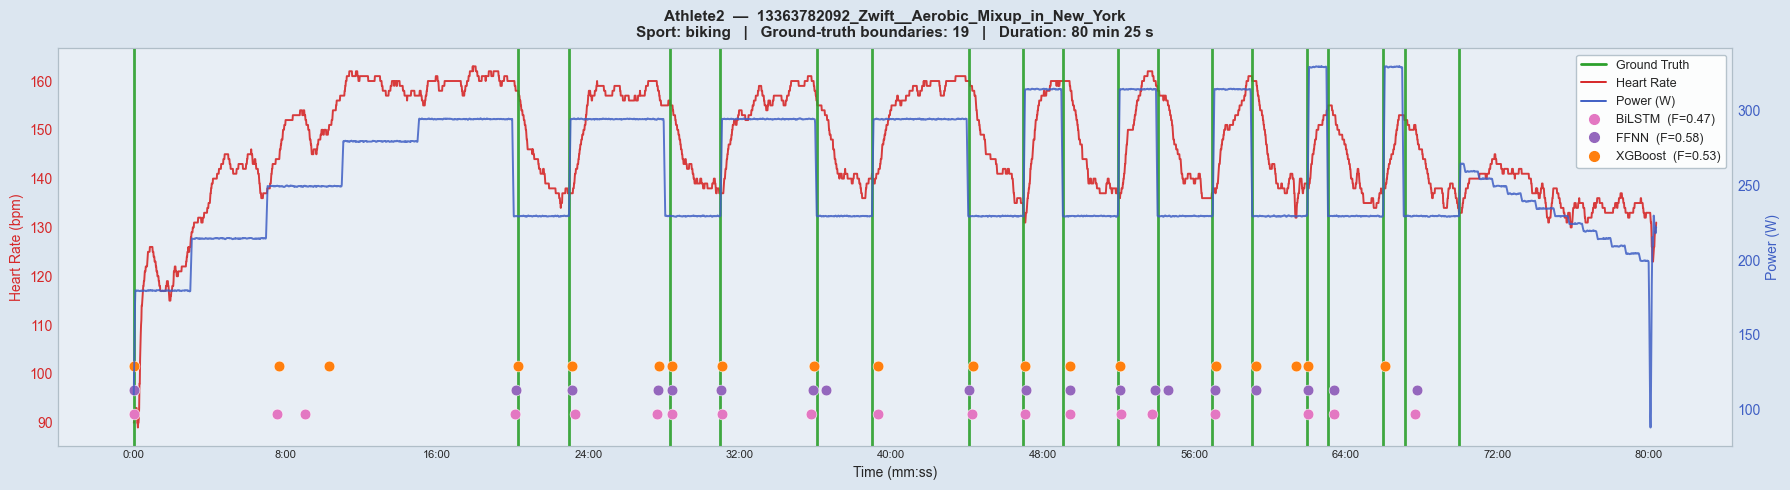

  Saved: plots/session_Athlete2_13363782092_Zwift__Aerobic_Mixup_in_New_York.png


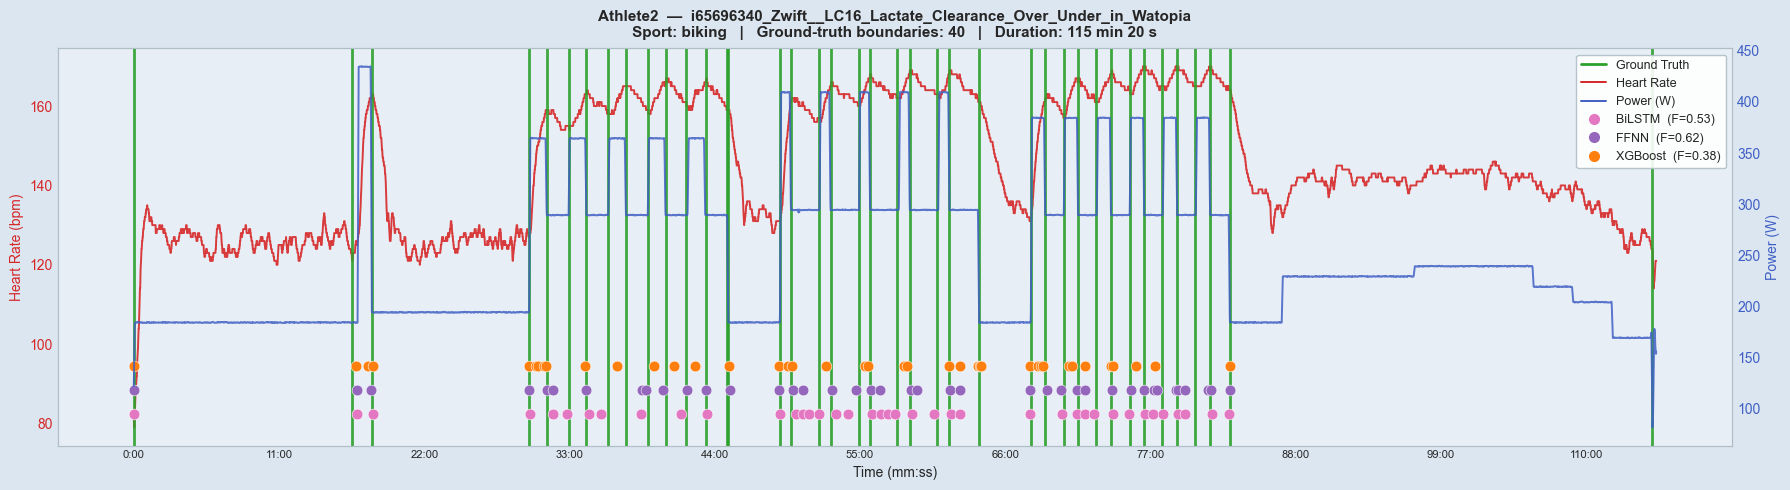

  Saved: plots/session_Athlete2_i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia.png


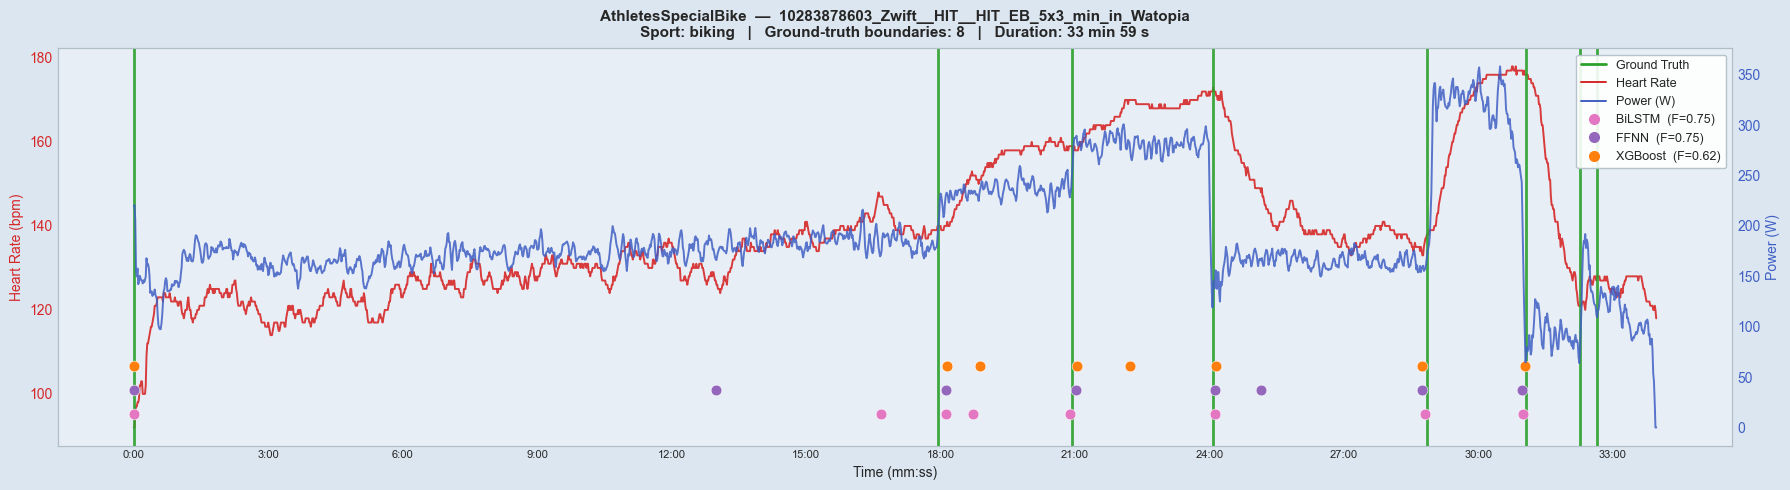

  Saved: plots/session_AthletesSpecialBike_10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia.png


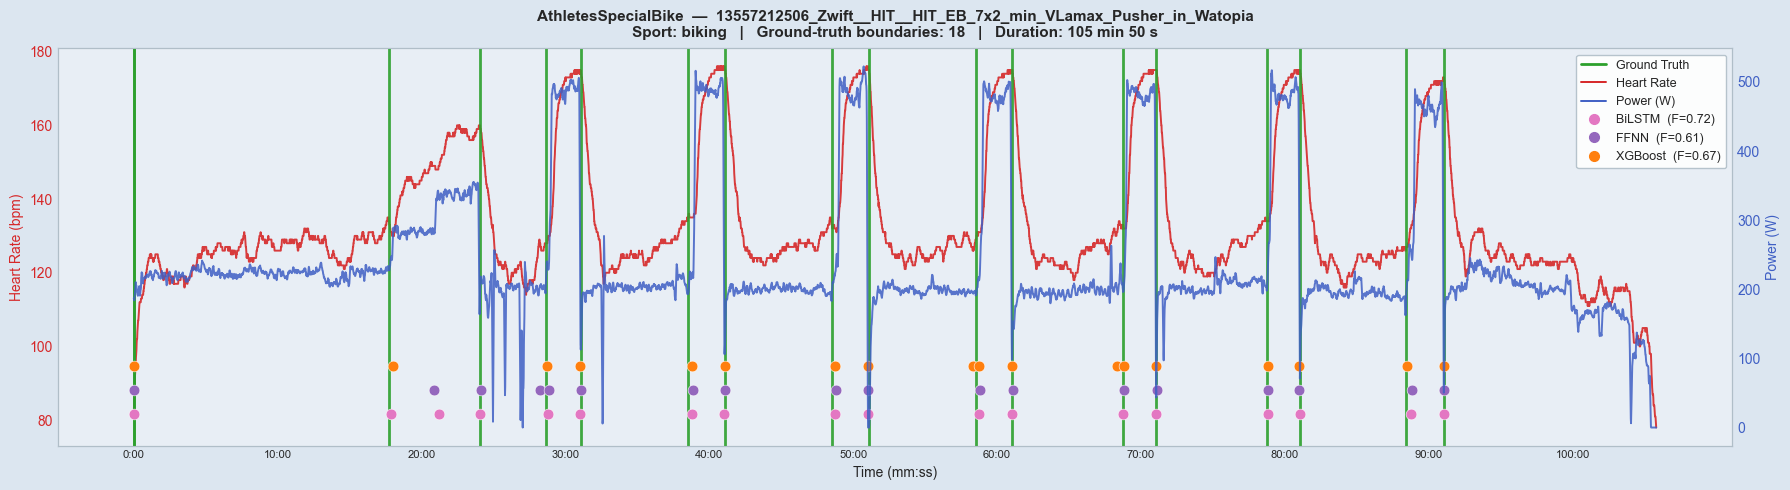

  Saved: plots/session_AthletesSpecialBike_13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia.png


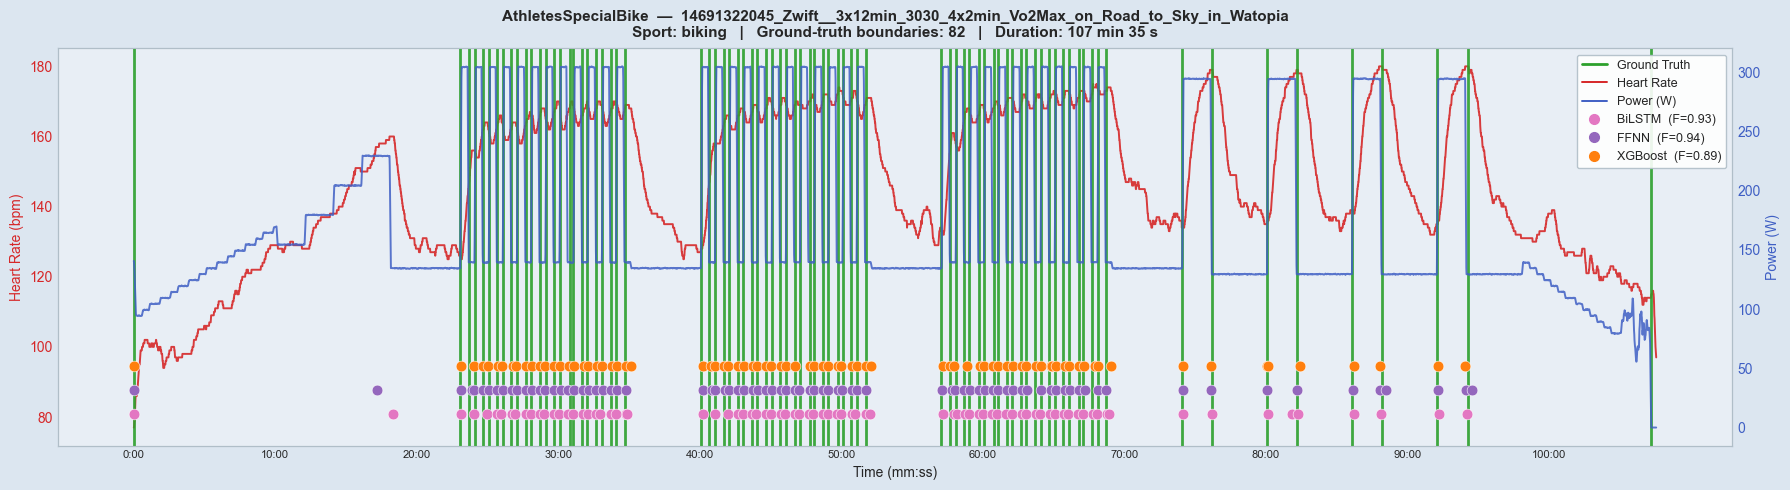

  Saved: plots/session_AthletesSpecialBike_14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia.png


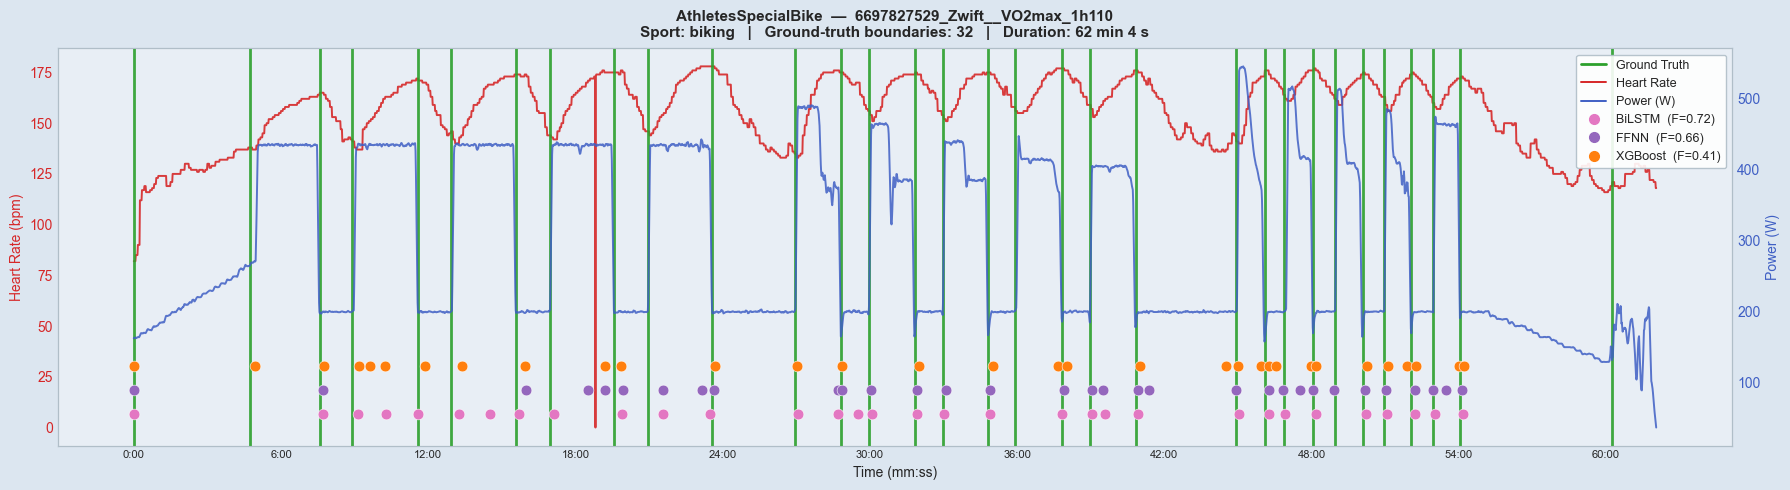

  Saved: plots/session_AthletesSpecialBike_6697827529_Zwift__VO2max_1h110.png


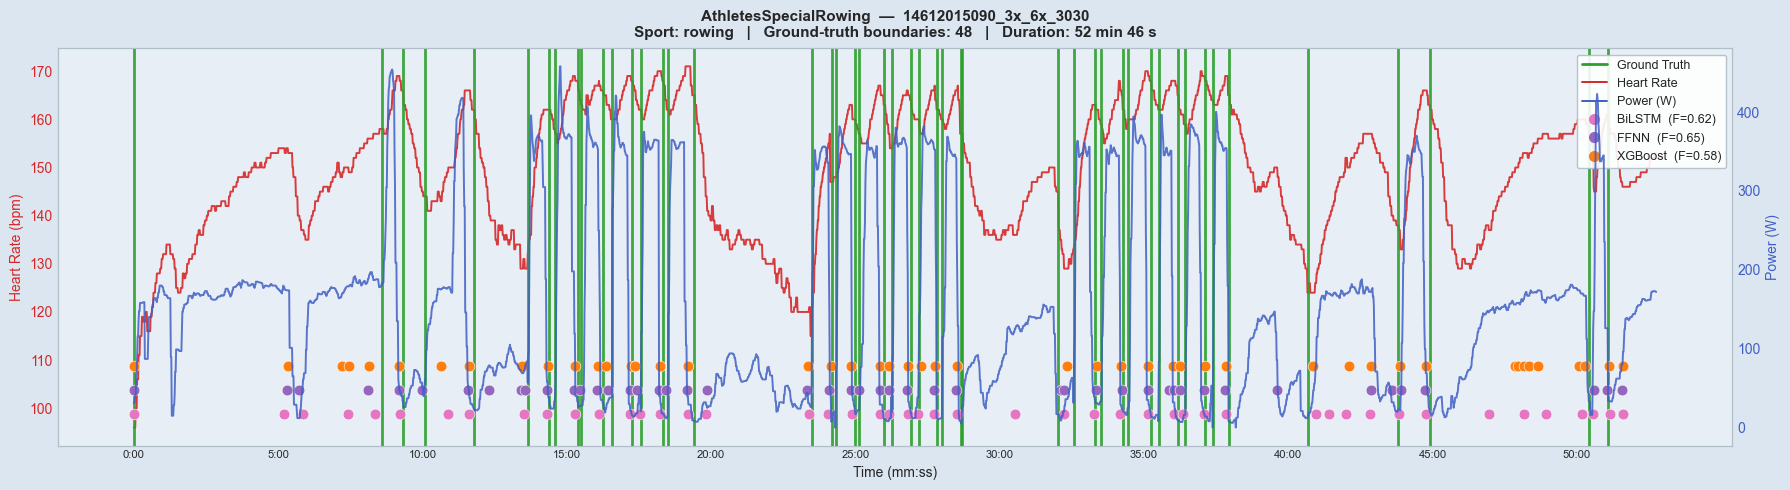

  Saved: plots/session_AthletesSpecialRowing_14612015090_3x_6x_3030.png


In [14]:
# ============================================================================
# SESSION VISUALIZATIONS — XGBoost, FFNN, BiLSTM Predictions
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pickle
import os
from collections import defaultdict

# ── Load raw results ──────────────────────────────────────────────────────
_MODEL_FILES_VIZ = {
    "BiLSTM":  "results/bilstm_results.pkl",
    "FFNN":    "results/nn_results.pkl",
    "XGBoost": "results/xgboost_results.pkl",
}

MODEL_COLORS = {
    "BiLSTM":  "#e377c2",   # pink
    "FFNN":    "#9467bd",   # purple
    "XGBoost": "#ff7f0e",   # orange
}
VIZ_MODELS = ["BiLSTM", "FFNN", "XGBoost"]

# Each model gets its own fixed lane (axes y-coordinate, 0=bottom 1=top)
MODEL_LANES = {"BiLSTM": 0.08, "FFNN": 0.14, "XGBoost": 0.20}

# Style constants
BG_OUTER  = "#dce6f0"
BG_INNER  = "#e8eef5"
HR_COLOR  = "#d62728"
POWER_COL = "#3f5fc4"
GT_COLOR  = "#2ca02c"

session_data = defaultdict(dict)

for model_display, fpath in _MODEL_FILES_VIZ.items():
    with open(fpath, "rb") as f:
        pkg = pickle.load(f)
    results_list = pkg["results"] if isinstance(pkg, dict) else pkg
    for r in results_list:
        key = (r["athlete"], r["session"])
        if "df" not in session_data[key]:
            session_data[key]["df"]      = r["df"]
            session_data[key]["y_true"]  = r["y_true"]
            session_data[key]["athlete"] = r["athlete"]
            session_data[key]["session"] = r["session"]
            session_data[key]["sport"]   = get_sport(r["athlete"])
        session_data[key][model_display] = {
            "y_pred": r["y_pred"],
            "f_beta": r["f_beta"],
        }

print(f"Loaded {len(session_data)} sessions.")

os.makedirs("plots", exist_ok=True)

# ── One figure per session ────────────────────────────────────────────────
for (athlete, session), data in sorted(session_data.items()):
    df     = data["df"]
    y_true = data["y_true"]
    n      = len(y_true)
    t      = np.arange(n)
    gt_cps = np.where(y_true == 1)[0]

    hr_col    = next((c for c in ["hr", "heart_rate", "HR"] if c in df.columns), None)
    power_col = next((c for c in ["power", "Power"]         if c in df.columns), None)

    hr_vals    = df[hr_col].values[:n]    if hr_col    else None
    power_vals = df[power_col].values[:n] if power_col else None

    fig, ax1 = plt.subplots(figsize=(18, 5))
    fig.patch.set_facecolor(BG_OUTER)
    ax1.set_facecolor(BG_INNER)
    ax1.grid(False)
    ax1.tick_params(which="both", length=0)
    for spine in ax1.spines.values():
        spine.set_edgecolor("#b0bec8")

    # ── HR line (red, left axis) ──────────────────────────────────────────
    if hr_vals is not None:
        ax1.plot(t, hr_vals, color=HR_COLOR, alpha=0.9, linewidth=1.4, zorder=3)
        ax1.set_ylabel("Heart Rate (bpm)", color=HR_COLOR, fontsize=10)
        ax1.tick_params(axis="y", labelcolor=HR_COLOR, length=0)
    else:
        ax1.set_ylabel("Heart Rate (bpm)", fontsize=10)

    # ── Power line (strong blue, right axis) ─────────────────────────────
    if power_vals is not None:
        ax2 = ax1.twinx()
        ax2.grid(False)
        ax2.set_facecolor(BG_INNER)
        ax2.plot(t, power_vals, color=POWER_COL, alpha=0.85, linewidth=1.4, zorder=2)
        ax2.set_ylabel("Power (W)", color=POWER_COL, fontsize=10)
        ax2.tick_params(which="both", length=0, labelcolor=POWER_COL)
        for spine in ax2.spines.values():
            spine.set_edgecolor("#b0bec8")

    # ── Ground truth — solid green vertical lines ─────────────────────────
    for cp in gt_cps:
        ax1.axvline(cp, color=GT_COLOR, linewidth=2.0, alpha=0.9, zorder=5)

    # ── Model predictions — each model in its own fixed lane ─────────────
    xform = ax1.get_xaxis_transform()
    for model in VIZ_MODELS:
        if model not in data:
            continue
        pred_cps = np.where(data[model]["y_pred"] == 1)[0]
        if len(pred_cps) == 0:
            continue
        ax1.scatter(pred_cps, [MODEL_LANES[model]] * len(pred_cps),
                    transform=xform,
                    color=MODEL_COLORS[model], s=60, zorder=6,
                    marker="o", edgecolors="white", linewidths=0.4)

    # ── Legend ────────────────────────────────────────────────────────────
    legend_items = [
        mlines.Line2D([], [], color=GT_COLOR, linewidth=2.0, label="Ground Truth"),
    ]
    if hr_vals is not None:
        legend_items.append(mlines.Line2D([], [], color=HR_COLOR, linewidth=1.4, label="Heart Rate"))
    if power_vals is not None:
        legend_items.append(mlines.Line2D([], [], color=POWER_COL, linewidth=1.4, label="Power (W)"))
    for m in VIZ_MODELS:
        if m in data:
            legend_items.append(
                mlines.Line2D([], [], color=MODEL_COLORS[m], linewidth=0,
                              marker="o", markersize=7,
                              label=f"{m}  (F={data[m]['f_beta']:.2f})")
            )
    ax1.legend(handles=legend_items, loc="upper right", fontsize=9,
               framealpha=0.9, facecolor="white", edgecolor="#b0bec8")

    # ── Title & axes ──────────────────────────────────────────────────────
    ax1.set_title(
        f"{data['athlete']}  —  {session}\n"
        f"Sport: {data['sport']}   |   Ground-truth boundaries: {len(gt_cps)}   |   "
        f"Duration: {n // 60} min {n % 60} s",
        fontsize=11, fontweight="bold", pad=8,
    )
    tick_step = max(60, (n // 10 // 60) * 60)
    tick_pos  = np.arange(0, n, tick_step)
    ax1.set_xticks(tick_pos)
    ax1.set_xticklabels([f"{int(p // 60)}:{int(p % 60):02d}" for p in tick_pos], fontsize=8)
    ax1.set_xlabel("Time (mm:ss)", fontsize=10)

    plt.tight_layout()
    safe      = "".join(c for c in f"{athlete}_{session}".replace(" ", "_") if c.isalnum() or c in "_-")
    fpath_out = f"plots/session_{safe}.png"
    plt.savefig(fpath_out, dpi=110, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {fpath_out}")